# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

In [6]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

C:\Users\Ibraheem khan\anaconda3\envs\tf_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [7]:
checkpoints = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [8]:
train_dir = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\train'
validation_dir = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\validation'
test_dir = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\test'

In [9]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

C:\Users\Ibraheem khan\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [12]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [13]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [14]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=5,
                    callbacks=callbacks)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.3624 - loss: 1.2937
Epoch 1: val_loss improved from None to 0.62579, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0001-loss0.63.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - acc: 0.4831 - loss: 1.1145 - val_acc: 0.8175 - val_loss: 0.6258
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.7380 - loss: 0.6309
Epoch 2: val_loss improved from 0.62579 to 0.46193, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0002-loss0.46.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - acc: 0.7469 - loss: 0.6000 - val_acc: 0.8016 - val_loss: 0.4619
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8127 - loss: 0.4566
Epoch 3: val_loss improved from 0.46193 to 0.46037, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0003-loss0.46.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.7956 - loss: 0.4718 - val_acc: 0.7897 - val_loss: 0.4604
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8127 - loss: 0.4227
Epoch 4: val_loss improved from 0.46037 to 0.35748, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0004-loss0.36.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.8150 - loss: 0.4092 - val_acc: 0.8135 - val_loss: 0.3575
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8447 - loss: 0.3364
Epoch 5: val_loss did not improve from 0.35748
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.8350 - loss: 0.3492 - val_acc: 0.7817 - val_loss: 0.3767


In [15]:
model_history.history

{'acc': [0.4831250011920929,
  0.746874988079071,
  0.7956249713897705,
  0.8149999976158142,
  0.8349999785423279],
 'loss': [1.1144870519638062,
  0.6000317335128784,
  0.47183528542518616,
  0.4092073142528534,
  0.3491899371147156],
 'val_acc': [0.817460298538208,
  0.8015872836112976,
  0.7896825671195984,
  0.8134920597076416,
  0.7817460298538208],
 'val_loss': [0.6257889270782471,
  0.4619293510913849,
  0.4603726267814636,
  0.3574758470058441,
  0.3766709268093109]}

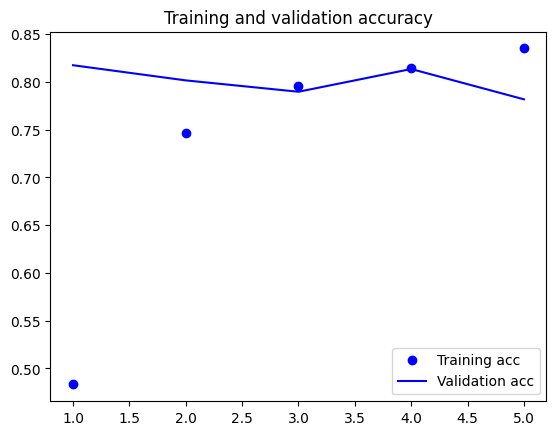

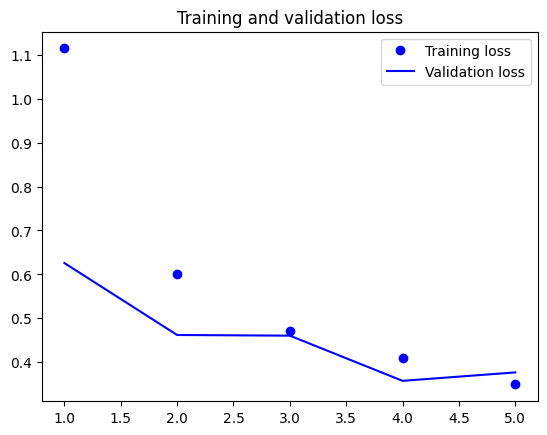

<Figure size 640x480 with 0 Axes>

In [16]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\model_Accuracy.png')

In [17]:
model.save(r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\E1-cp-0012-loss0.21.h5')

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step


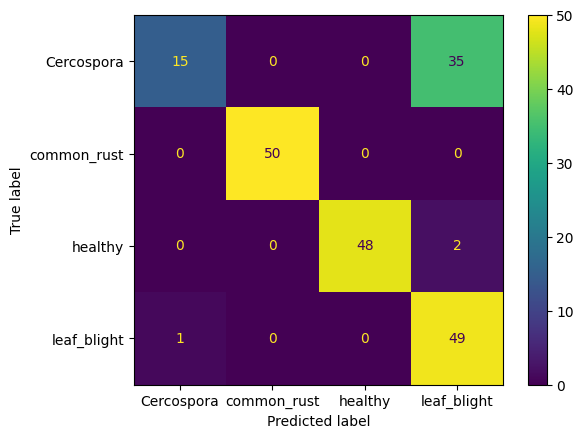

In [18]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [19]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.94      0.30      0.45        50
 common_rust       1.00      1.00      1.00        50
     healthy       1.00      0.96      0.98        50
 leaf_blight       0.57      0.98      0.72        50

    accuracy                           0.81       200
   macro avg       0.88      0.81      0.79       200
weighted avg       0.88      0.81      0.79       200

